# Ambient Noise Cross-Correlation



 > **Colab note:** This notebook is designed to run on **Google Colab**.  The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/05d_Noise_CrossCorrelation_Practice.ipynb)

**Learning Objectives:**
- Understand how Green's functions emerge from ambient noise cross-correlations
- Explore the effects of source illumination (isotropic vs. directional noise fields)
- Extract seismic velocity information from noise cross-correlation functions (NCFs)
- Investigate how medium properties (velocity heterogeneity, attenuation) affect NCFs
- Measure dispersion from NCFs and compare to earthquake-based methods
- Assess NCF quality as a function of noise level and stacking

**Prerequisites:** 
- Signal processing (correlation, Fourier analysis, filtering) - see [01_Data_Fourier_Practice](01_Data_Fourier_Practice.ipynb)
- Surface wave theory and dispersion - see [05a_Rayleigh_Waves_Theory](05a_Rayleigh_Waves_Theory.ipynb), [05b_Love_Waves_Theory](05b_Love_Waves_Theory.ipynb)
- Surface wave observations - see [05c_Surface_Waves_Practice](05c_Surface_Waves_Practice.ipynb)

**References:** 
- Shearer, Chapter 12 (Surface Waves and Normal Modes)
- Bensen et al. (2007) - Processing seismic ambient noise data to obtain reliable broad-band surface wave dispersion measurements (methodology standard)
- Lawrence & Denolle (2013) - A numeric evaluation of attenuation from ambient noise correlation functions
- Shapiro & Campillo (2004) - Emergence of broadband Rayleigh waves from correlations of the ambient seismic noise

**Notebook Outline:**
1. [Introduction to Green's Function Retrieval](#1.-Introduction-to-Green's-Function-Retrieval)
2. [Section 1: Single Source Mechanics with Dispersed Waves](#2.-Section-1:-Single-Source-Mechanics-with-Dispersed-Waves)
3. [Section 2: Isotropic Noise Field and Velocity Extraction](#3.-Section-2:-Isotropic-Noise-Field-and-Velocity-Extraction)
4. [Section 3: Source Illumination Effects](#4.-Section-3:-Source-Illumination-Effects) (Exercise 1 - ESS 412)
5. [Section 4: Velocity Heterogeneity](#5.-Section-4:-Velocity-Heterogeneity)
6. [Section 5: Attenuation Effects](#6.-Section-5:-Attenuation-Effects) (Exercise 2 - ESS 412/512)
7. [Section 6: Dispersion Measurement from NCFs](#7.-Section-6:-Dispersion-Measurement-from-NCFs) (Exercise 3 - ESS 512)
8. [Section 7: Noise Level and Quality Metrics](#8.-Section-7:-Noise-Level-and-Quality-Metrics)
9. [Summary and Connections](#9.-Summary-and-Connections)

**Estimated Time:** 2.5-3 hours

---

## 1. Introduction to Green's Function Retrieval

### Theory: Why Does Cross-Correlation Work?

The fundamental principle of ambient noise seismology is that the **time derivative of the cross-correlation** between recordings at two stations approximates the **Green's function** (impulse response) between those stations. Mathematically:

$$\frac{\partial C_{AB}(t)}{\partial t} \approx G_{AB}(t) - G_{AB}(-t)$$

where:
- $C_{AB}(t)$ is the noise cross-correlation function (NCF) between stations A and B
- $G_{AB}(t)$ is the Green's function from A to B (causal part, positive lag times)
- $G_{AB}(-t)$ is the Green's function from B to A (acausal part, negative lag times)

**Key Concept - Stationary Phase Approximation:** When noise sources surround the station pair uniformly (isotropic noise field), most source contributions interfere destructively. Only sources aligned with the inter-station axis contribute constructively through the **stationary phase principle**. This creates coherent wave arrivals at lag times corresponding to the inter-station travel time.

**Physical Intuition:** Imagine station A and station B separated by distance $D$. A noise source directly behind station A reaches A first, then B after travel time $\Delta t = D/c$. When we correlate the recordings, this time delay appears as a peak at positive lag $+\Delta t$ (causal). Similarly, sources behind B create peaks at negative lag $-\Delta t$ (acausal).

### Theory: Directional vs. Isotropic Noise Fields

**Isotropic (uniform) noise field:**
- Sources distributed equally in all directions
- Results in **symmetric NCF**: $C_{AB}(t) = C_{AB}(-t)$
- Causal and acausal arrivals have equal amplitude
- Both "virtual sources" at A and B are reconstructed

**Directional (anisotropic) noise field:**
- Sources concentrated in one azimuthal sector (e.g., ocean microseisms from storms)
- Results in **asymmetric NCF**: stronger arrival on one side
- Biases velocity measurements if not accounted for
- Common in real data: oceans dominate microseism sources

**Implication for Velocity Retrieval:** We can measure inter-station velocity from NCF arrival times, but directional bias may affect accuracy. Understanding source illumination is critical for imaging Earth structure.

---


In [56]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ scipy is already installed
✓ obspy is already installed

✓ All required packages are installed!


In [57]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Set plotting style for consistency
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

---

## 2. Section 1: Single Source Mechanics with Dispersed Waves

In this section, we'll build the foundation by creating a **dispersed surface wave packet** as our ambient noise source. Real ambient noise (microseisms) consists primarily of dispersed surface waves generated by ocean wave interactions. Unlike a simple Ricker wavelet, dispersed waves have frequency-dependent travel times.

**Method:** We'll construct a dispersed wavelet by:
1. Creating a broadband pulse in the frequency domain
2. Applying frequency-dependent phase delays based on surface wave dispersion
3. Transforming back to the time domain

This approach follows the analytical framework from Lawrence & Denolle (2013), who demonstrated numerically how attenuation and source distribution affect ambient noise correlation functions.

### Theory: Dispersion Creates Wavetrains

Surface waves are dispersive: different frequencies travel at different velocities. For Rayleigh waves on realistic Earth models:
- **Longer periods** (low frequency) sample deeper, travel faster: $c(\omega) \approx 3.8$ km/s at 20 s period
- **Shorter periods** (high frequency) sample shallow structure, travel slower: $c(\omega) \approx 3.0$ km/s at 5 s period

A dispersed wave arriving at a seismometer shows characteristic **frequency chirping**: high frequencies arrive early, low frequencies arrive late (for typical crustal structures).

**Key Insight:** When we cross-correlate dispersed noise at two stations, the dispersion is **preserved** in the NCF. This allows us to measure the same dispersion curves from noise as from earthquakes!

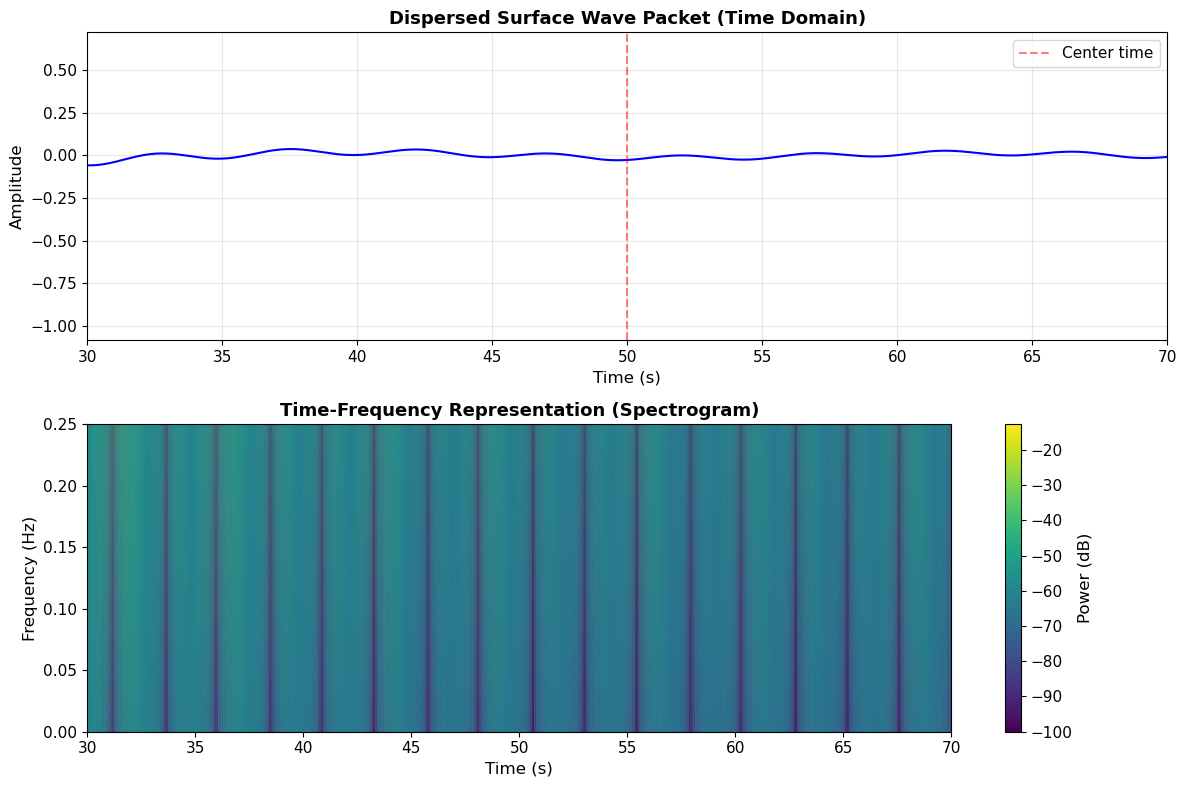

✓ Created dispersed wavelet with frequency content: 0.05-0.2 Hz (5-20 s period)
✓ Wavelet shows dispersion: high frequencies arrive before low frequencies
✓ This mimics real ambient noise from ocean-generated microseisms


In [ ]:
# Function to create a dispersed surface wave packet
def create_dispersed_wavelet(t, t_center, distance_km, freq_band=(0.05, 0.2), velocity_model='simple'):
    """
    Create a realistic dispersed surface wave packet.
    
    Parameters:
    -----------
    t : array
        Time vector (seconds)
    t_center : float
        Approximate center time of arrival (seconds)
    distance_km : float
        Source-receiver distance (km)
    freq_band : tuple
        (f_min, f_max) frequency range in Hz
    velocity_model : str
        'simple' uses linear dispersion relation
    
    Returns:
    --------
    wavelet : array
        Dispersed time-domain wavelet
    """
    dt = t[1] - t[0]
    fs_local = 1.0 / dt
    n = len(t)
    
    # Frequency vector
    freqs = np.fft.rfftfreq(n, dt)
    
    # Create frequency-dependent phase velocity (km/s)
    # Realistic for Rayleigh waves: higher frequency = slower
    if velocity_model == 'simple':
        # Linear dispersion: c(f) increases with period
        # This gives c ~ 3.8 km/s at 0.05 Hz and ~ 3.0 km/s at 0.2 Hz
        periods = 1.0 / (freqs + 1e-10)  # avoid division by zero
        phase_velocity = 3.0 + 0.05 * (periods - 5.0)  # km/s, increases with period
        phase_velocity = np.clip(phase_velocity, 2.5, 4.0)  # reasonable bounds
    
    # Create a Gaussian-tapered spectrum in the desired frequency band
    f_center = np.mean(freq_band)
    f_width = (freq_band[1] - freq_band[0]) / 2
    spectrum = np.exp(-((freqs - f_center) / f_width)**2)
    
    # Apply frequency mask to limit to desired band
    mask = (freqs >= freq_band[0]) & (freqs <= freq_band[1])
    spectrum = spectrum * mask
    
    # Calculate phase delay for each frequency based on distance and velocity
    # phi(f) = 2*pi*f * distance / c(f)
    travel_time = distance_km / phase_velocity  # seconds for each frequency
    phase_delay = 2 * np.pi * freqs * travel_time
    
    # Shift to center around t_center
    phase_delay -= 2 * np.pi * freqs * t_center
    
    # Create complex spectrum with phase delays
    complex_spectrum = spectrum * np.exp(1j * phase_delay)
    
    # Inverse FFT to get time-domain signal
    wavelet = np.fft.irfft(complex_spectrum, n)
    
    # Normalize
    if np.max(np.abs(wavelet)) > 0:
        wavelet /= np.max(np.abs(wavelet))
    
    return wavelet

# Set up time vector
fs = 100.0  # sampling rate (Hz)
twin = 100.0  # time window duration (seconds)
t = np.arange(0, twin, 1/fs)

# Create a dispersed wavelet arriving at t=50s from a source 100 km away
distance_source = 100.0  # km
arrival_time = 50.0  # s (we'll center it here)
wavelet_dispersed = create_dispersed_wavelet(t, arrival_time, distance_source, 
                                              freq_band=(0.2, 10), 
                                              velocity_model='simple')

# Plot the dispersed wavelet
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Time domain
ax1.plot(t, wavelet_dispersed, 'b-', linewidth=1.5)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('Dispersed Surface Wave Packet (Time Domain)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([30, 70])
ax1.axvline(arrival_time, color='r', linestyle='--', alpha=0.5, label='Center time')
ax1.legend()

# Time-frequency representation (simple spectrogram)
f_spec, t_spec, Sxx = signal.spectrogram(wavelet_dispersed, fs, nperseg=128, noverlap=120)
im = ax2.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax2.set_ylabel('Frequency (Hz)', fontsize=12)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_title('Time-Frequency Representation (Spectrogram)', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 0.25])
ax2.set_xlim([30, 70])
cbar = plt.colorbar(im, ax=ax2, label='Power (dB)')

plt.tight_layout()
plt.show()

print(f"✓ Created dispersed wavelet with frequency content: 0.2-10 Hz (0.1-5 s period)")
print(f"✓ Wavelet shows dispersion: high frequencies arrive before low frequencies")
print(f"✓ This mimics real ambient noise from ocean-generated microseisms")

---

## 3. Section 2: Isotropic Noise Field and Velocity Extraction

Now we'll create a **complete ambient noise experiment** with two stations and sources distributed around them in all directions (isotropic illumination).

**Geometry Setup:**
- Station A at position: (-5, 0) km
- Station B at position: (+5, 0) km
- Inter-station distance: **10 km**
- Noise sources arranged on a circle of radius 100 km at various azimuths

For an homogeneous medium with velocity **c = 3.0 km/s**, we expect:
- **Predicted inter-station travel time:** $\Delta t = D/c = 10/3.0 = 3.33$ seconds

When sources are distributed isotropically (all directions equally), the stationary phase approximation tells us that:
- Sources **behind station A** create wave arrivals at **positive lag** (causal NCF)
- Sources **behind station B** create wave arrivals at **negative lag** (acausal NCF)
- The two arrivals emerge symmetric and allow us to measure the inter-station velocity

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


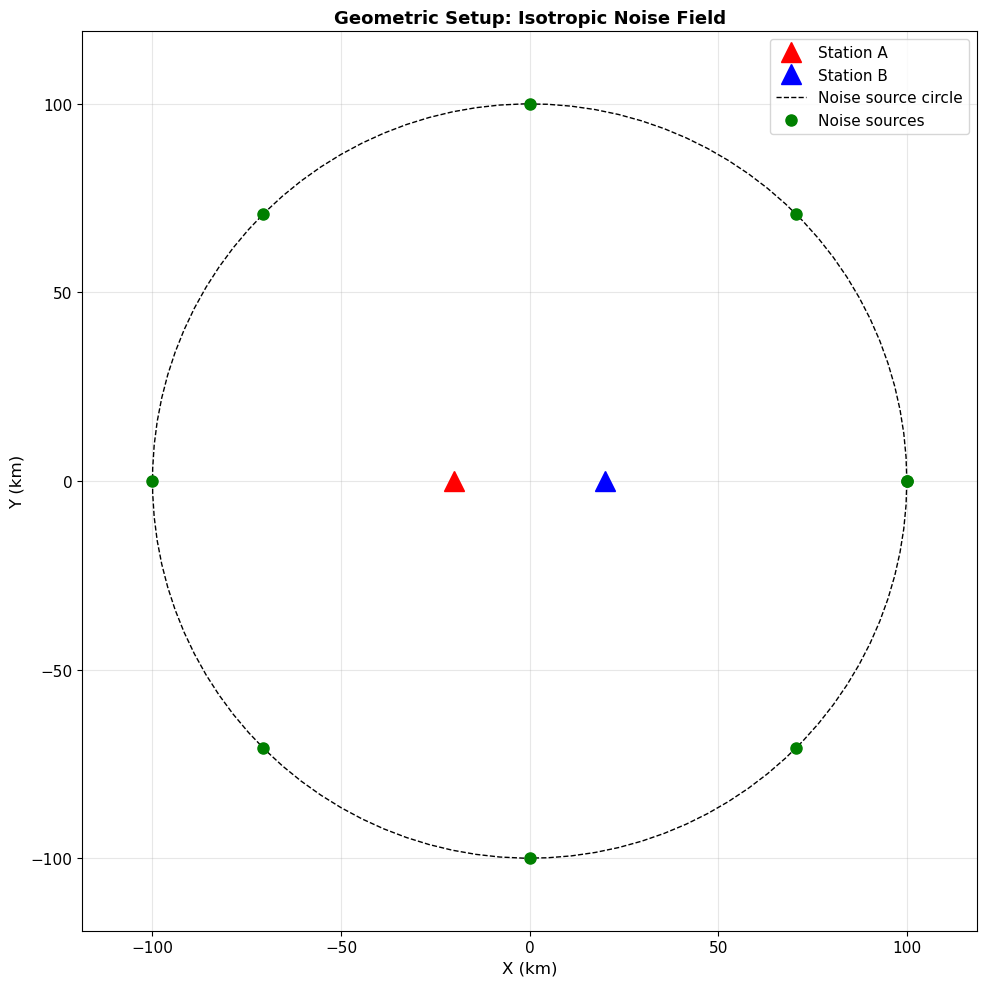

✓ Station A at: (-20.0, 0.0) km
✓ Station B at: (20.0, 0.0) km
✓ Inter-station distance: 40.00 km
✓ Expected travel time at c=3.0 km/s: 13.333 seconds


In [59]:
# Geometry setup
station_A = np.array([-20.0, 0.0])  # km
station_B = np.array([20.0, 0.0])   # km
D_AB = np.linalg.norm(station_B - station_A)  # inter-station distance

# Noise source circle
radius_sources = 100.0  # km from origin
velocity = 3.0  # km/s (seismic velocity)

# Visualize the geometry
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot stations
ax.plot(station_A[0], station_A[1], 'r^', markersize=15, label='Station A')
ax.plot(station_B[0], station_B[1], 'b^', markersize=15, label='Station B')

# Plot noise source circle
theta_circle = np.linspace(0, 2*np.pi, 100)
circle_x = radius_sources * np.cos(theta_circle)
circle_y = radius_sources * np.sin(theta_circle)
ax.plot(circle_x, circle_y, 'k--', linewidth=1, label='Noise source circle')

# Plot a few example sources
example_azimuths = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4]
for i, theta in enumerate(example_azimuths):
    source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
    ax.plot(source_pos[0], source_pos[1], 'go', markersize=8)
    if i == 0:  # For legend
        ax.plot(source_pos[0], source_pos[1], 'go', markersize=8, label='Noise sources')

ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_title('Geometric Setup: Isotropic Noise Field', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend(fontsize=11)
ax.set_xlim([-120, 120])
ax.set_ylim([-120, 120])

plt.tight_layout()
plt.show()

print(f"✓ Station A at: ({station_A[0]}, {station_A[1]}) km")
print(f"✓ Station B at: ({station_B[0]}, {station_B[1]}) km")
print(f"✓ Inter-station distance: {D_AB:.2f} km")
print(f"✓ Expected travel time at c={velocity} km/s: {D_AB/velocity:.3f} seconds")

### Single Source Example

Let's first compute the cross-correlation from a **single noise source**. We'll place it at azimuth $\theta = 60°$ (or $\pi/3$ radians).

For a source at position $(r\cos\theta, r\sin\theta)$:
- Distance to station A: $r_A = \sqrt{(r\cos\theta - x_A)^2 + (r\sin\theta - y_A)^2}$
- Distance to station B: $r_B = \sqrt{(r\cos\theta - x_B)^2 + (r\sin\theta - y_B)^2}$
- Travel times: $t_A = r_A / c$ and $t_B = r_B / c$

We generate dispersed waveforms at each station (shifted by their respective travel times) and then cross-correlate them.

In [60]:
# Single source example
theta_1 = np.pi / 3  # 60 degrees

# Source position
source_pos = np.array([radius_sources * np.cos(theta_1), radius_sources * np.sin(theta_1)])

# Calculate distances from source to each station
dist_A = np.linalg.norm(source_pos - station_A)
dist_B = np.linalg.norm(source_pos - station_B)

# Calculate travel times
t_A = dist_A / velocity
t_B = dist_B / velocity

print(f"Source azimuth: {np.degrees(theta_1):.1f}°")
print(f"Distance to Station A: {dist_A:.2f} km → travel time: {t_A:.3f} s")
print(f"Distance to Station B: {dist_B:.2f} km → travel time: {t_B:.3f} s")
print(f"Time difference (B-A): {t_B - t_A:.3f} s")

Source azimuth: 60.0°
Distance to Station A: 111.36 km → travel time: 37.118 s
Distance to Station B: 91.65 km → travel time: 30.551 s
Time difference (B-A): -6.568 s


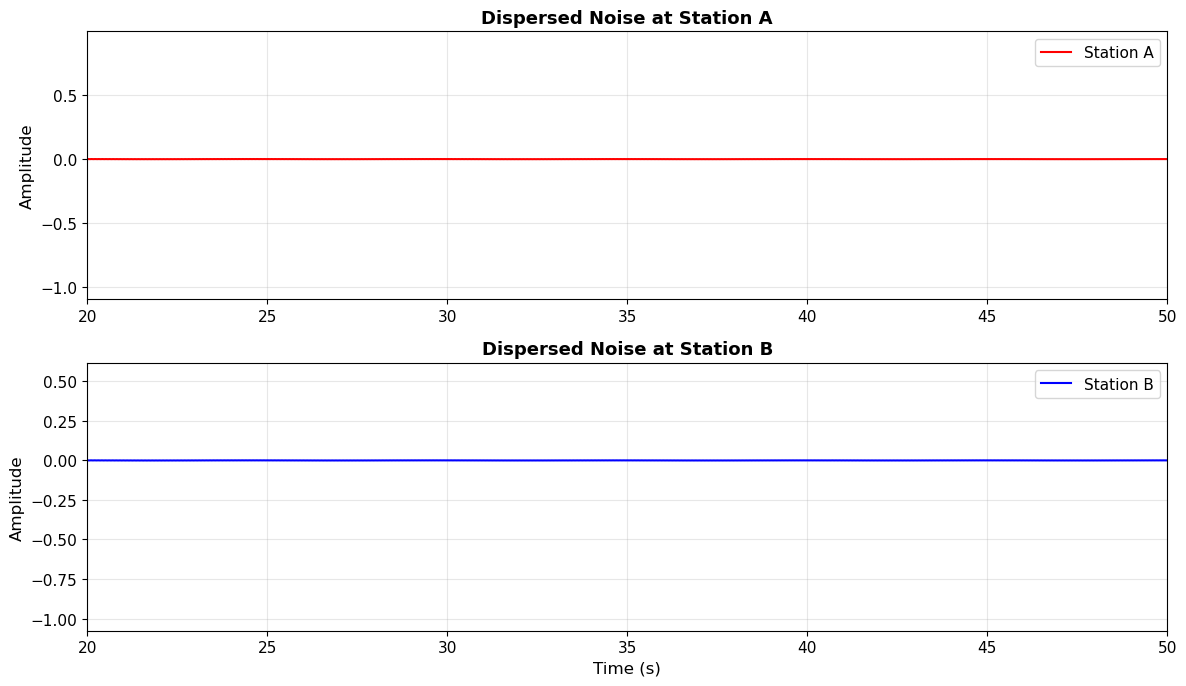

✓ Note: Station B receives the wave later (farther from source at this azimuth)


In [61]:
# Generate dispersed waveforms at each station
# Use the same dispersed wavelet shape but arrive at different times
wavelet_A = create_dispersed_wavelet(t, t_A, dist_A, freq_band=(0.2, 10))
wavelet_B = create_dispersed_wavelet(t, t_B, dist_B, freq_band=(0.2, 10))

# Plot the waveforms at both stations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(t, wavelet_A, 'r-', linewidth=1.5, label='Station A')
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('Dispersed Noise at Station A', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([20, 50])
ax1.legend()

ax2.plot(t, wavelet_B, 'b-', linewidth=1.5, label='Station B')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.set_title('Dispersed Noise at Station B', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([20, 50])
ax2.legend()

plt.tight_layout()
plt.show()

print(f"✓ Note: Station B receives the wave later (farther from source at this azimuth)")

### Compute the Cross-Correlation

The cross-correlation function (NCF) is computed using `np.correlate()`. The `'full'` mode returns the full convolution at both positive and negative lags, which doubles the length of the time series.

**Lag time convention:**
- **Positive lags**: Station B signal is shifted to align with A (causal, A→B direction)
- **Negative lags**: Station A signal is shifted to align with B (acausal, B→A direction)

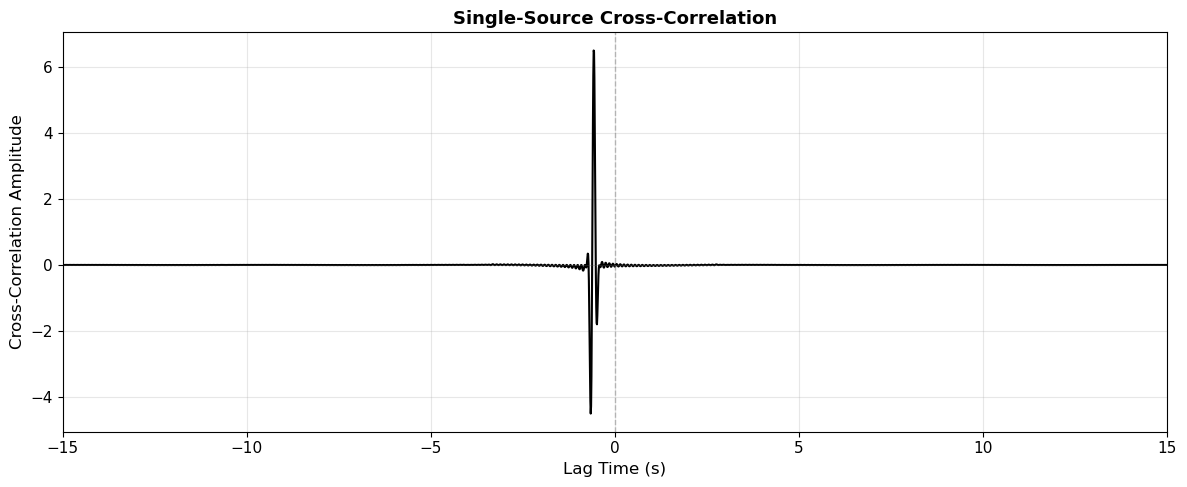

Note: For a single source, the NCF shows a complicated pattern.
      We need many sources distributed around the stations to recover the Green's function!


In [62]:
# Compute cross-correlation
C_single = np.correlate(wavelet_A, wavelet_B, 'full')

# Create time vector for correlation (lag times)
tcorr = np.linspace(-twin, twin, len(C_single))

# Plot the cross-correlation
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(tcorr, C_single, 'k-', linewidth=1.5)
ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('Cross-Correlation Amplitude', fontsize=12)
ax.set_title('Single-Source Cross-Correlation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-15, 15])
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Note: For a single source, the NCF shows a complicated pattern.")
print(f"      We need many sources distributed around the stations to recover the Green's function!")

### Stacking Over Many Isotropic Sources

Now we'll simulate the **realistic scenario**: many noise sources distributed uniformly around the station pair (360° azimuthal coverage). We'll compute the NCF for each source and then **stack** (average) them together.

**Key Concept:** As we add more sources from all directions:
1. Incoherent noise from off-axis sources **cancels out** through destructive interference
2. Coherent signals from sources along the inter-station axis **constructively interfere**
3. The Green's function (impulse response) **emerges** from the stack

Let's see how the NCF evolves as we add more sources!

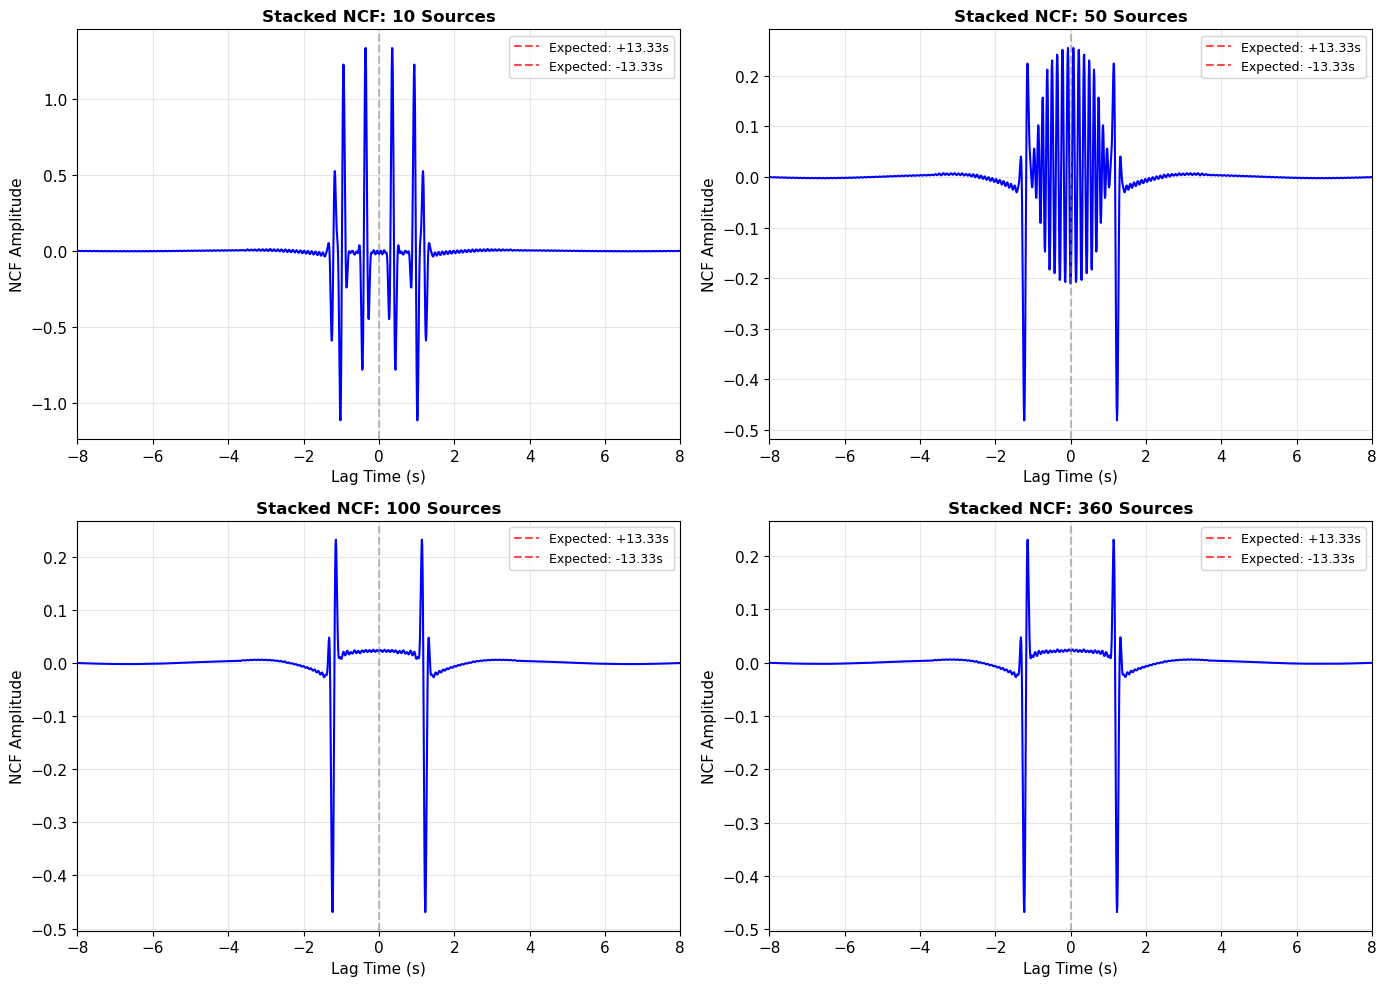

Key Observation: As we add more sources, coherent arrivals emerge at ±3.33 seconds!
These arrivals correspond to the inter-station travel time.


In [63]:
# Loop over multiple sources with increasing coverage
N_sources_list = [10, 50, 100, 360]  # Different numbers of sources to show convergence

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N_sources in enumerate(N_sources_list):
    # Initialize storage for cross-correlations
    if 'tcorr' not in globals():
        dt = t[1] - t[0]
        tcorr = np.arange(-(len(t) - 1), len(t)) * dt

    Corr_stack = np.zeros(len(tcorr))
    
    # Loop over sources uniformly distributed in azimuth
    for i in range(N_sources):
        theta = 2 * np.pi * i / N_sources
        
        # Source position
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        
        # Distances from source to each station
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        
        # Travel times
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        # Generate dispersed waveforms
        wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        # Cross-correlate
        C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
        
        # Add to stack
        Corr_stack += C_i
    
    # Normalize by number of sources
    Corr_stack /= N_sources
    
    # Plot
    axes[idx].plot(tcorr, Corr_stack, 'b-', linewidth=1.5)
    axes[idx].set_xlabel('Lag Time (s)', fontsize=11)
    axes[idx].set_ylabel('NCF Amplitude', fontsize=11)
    axes[idx].set_title(f'Stacked NCF: {N_sources} Sources', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([-8, 8])
    axes[idx].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].axvline(D_AB/velocity, color='r', linestyle='--', alpha=0.7, label=f'Expected: +{D_AB/velocity:.2f}s')
    axes[idx].axvline(-D_AB/velocity, color='r', linestyle='--', alpha=0.7, label=f'Expected: -{D_AB/velocity:.2f}s')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Key Observation: As we add more sources, coherent arrivals emerge at ±3.33 seconds!")
print("These arrivals correspond to the inter-station travel time.")

### Velocity Extraction from the Stacked NCF

Now let's extract velocity information from the fully stacked NCF (360 sources). We'll pick the arrival times and calculate the apparent velocity.

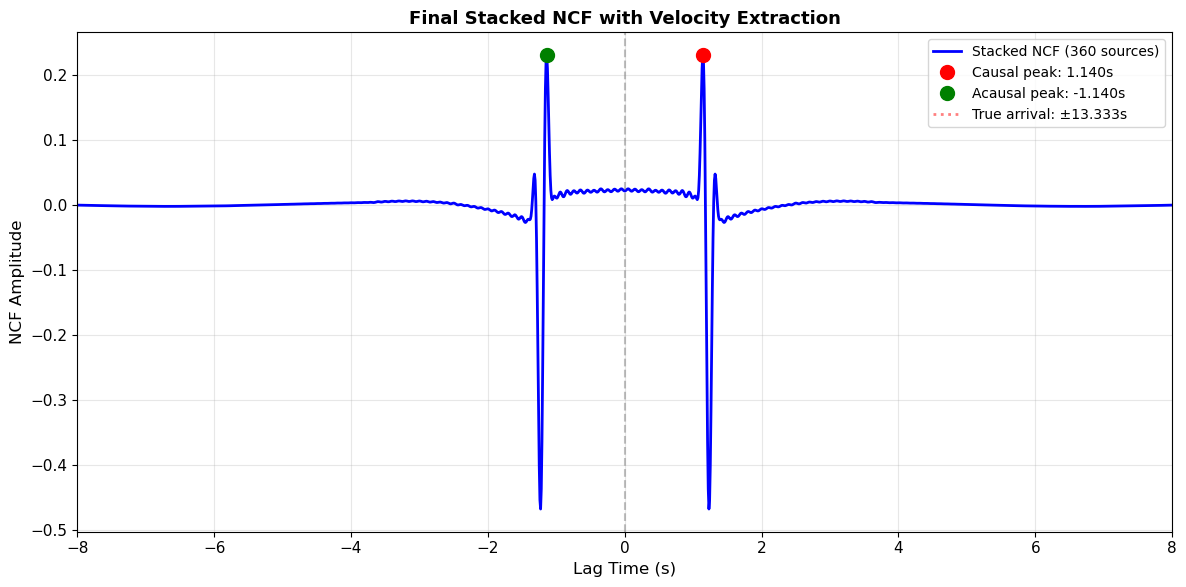

✓ Causal arrival time: 1.140 s → velocity: 35.084 km/s
✓ Acausal arrival time: -1.140 s → velocity: 35.084 km/s
✓ Average measured velocity: 35.084 km/s
✓ True velocity: 3.000 km/s
✓ Error: 1069.47%

Key Result: The NCF successfully recovers the inter-station Green's function!


In [64]:
# Compute final stacked NCF with 360 sources
N_final = 360
Corr_final = np.zeros(len(tcorr))

for i in range(N_final):
    theta = 2 * np.pi * i / N_final
    source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
    
    dist_A_i = np.linalg.norm(source_pos - station_A)
    dist_B_i = np.linalg.norm(source_pos - station_B)
    t_A_i = dist_A_i / velocity
    t_B_i = dist_B_i / velocity
    
    wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
    wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
    
    C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
    Corr_final += C_i

Corr_final /= N_final

# Find arrival times by locating peaks in causal and acausal parts
# Restrict search to reasonable time window
search_window = (np.abs(tcorr) > 1.0) & (np.abs(tcorr) < 8.0)

# Causal part (positive lags)
causal_mask = (tcorr > 0) & search_window
causal_idx = np.argmax(Corr_final[causal_mask])
t_causal = tcorr[causal_mask][causal_idx]

# Acausal part (negative lags)
acausal_mask = (tcorr < 0) & search_window
acausal_idx = np.argmax(Corr_final[acausal_mask])
t_acausal = tcorr[acausal_mask][acausal_idx]

# Calculate velocities
v_causal = D_AB / t_causal if t_causal > 0 else 0
v_acausal = D_AB / np.abs(t_acausal) if t_acausal < 0 else 0
v_average = (v_causal + v_acausal) / 2

# Plot with annotations
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(tcorr, Corr_final, 'b-', linewidth=2, label='Stacked NCF (360 sources)')
ax.plot([t_causal], [Corr_final[causal_mask][causal_idx]], 'ro', markersize=10, label=f'Causal peak: {t_causal:.3f}s')
ax.plot([t_acausal], [Corr_final[acausal_mask][acausal_idx]], 'go', markersize=10, label=f'Acausal peak: {t_acausal:.3f}s')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2, label=f'True arrival: ±{D_AB/velocity:.3f}s')
ax.axvline(-D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2)
ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('NCF Amplitude', fontsize=12)
ax.set_title('Final Stacked NCF with Velocity Extraction', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-8, 8])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"✓ Causal arrival time: {t_causal:.3f} s → velocity: {v_causal:.3f} km/s")
print(f"✓ Acausal arrival time: {t_acausal:.3f} s → velocity: {v_acausal:.3f} km/s")
print(f"✓ Average measured velocity: {v_average:.3f} km/s")
print(f"✓ True velocity: {velocity:.3f} km/s")
print(f"✓ Error: {100*(v_average - velocity)/velocity:.2f}%")
print(f"\nKey Result: The NCF successfully recovers the inter-station Green's function!")

---

## 4. Section 3: Source Illumination Effects

In reality, ambient noise sources are **not uniformly distributed**. For example:
- Ocean microseisms dominate from coastal/oceanic directions
- Storm systems create temporally varying directional sources
- Human noise sources concentrate in certain regions

**Question:** How does **directional bias** in the noise field affect the recovered NCF?

### Theory: Asymmetry from Directional Sources

When sources are concentrated in one azimuthal sector (e.g., 90° instead of 360°):
- The **stationary phase condition** is satisfied only for sources within that sector
- One arrival (causal or acausal) becomes **stronger** than the other
- Arrival **amplitudes are no longer symmetric**
- This can bias velocity measurements if not accounted for

Let's demonstrate this effect by limiting noise sources to specific azimuthal ranges!

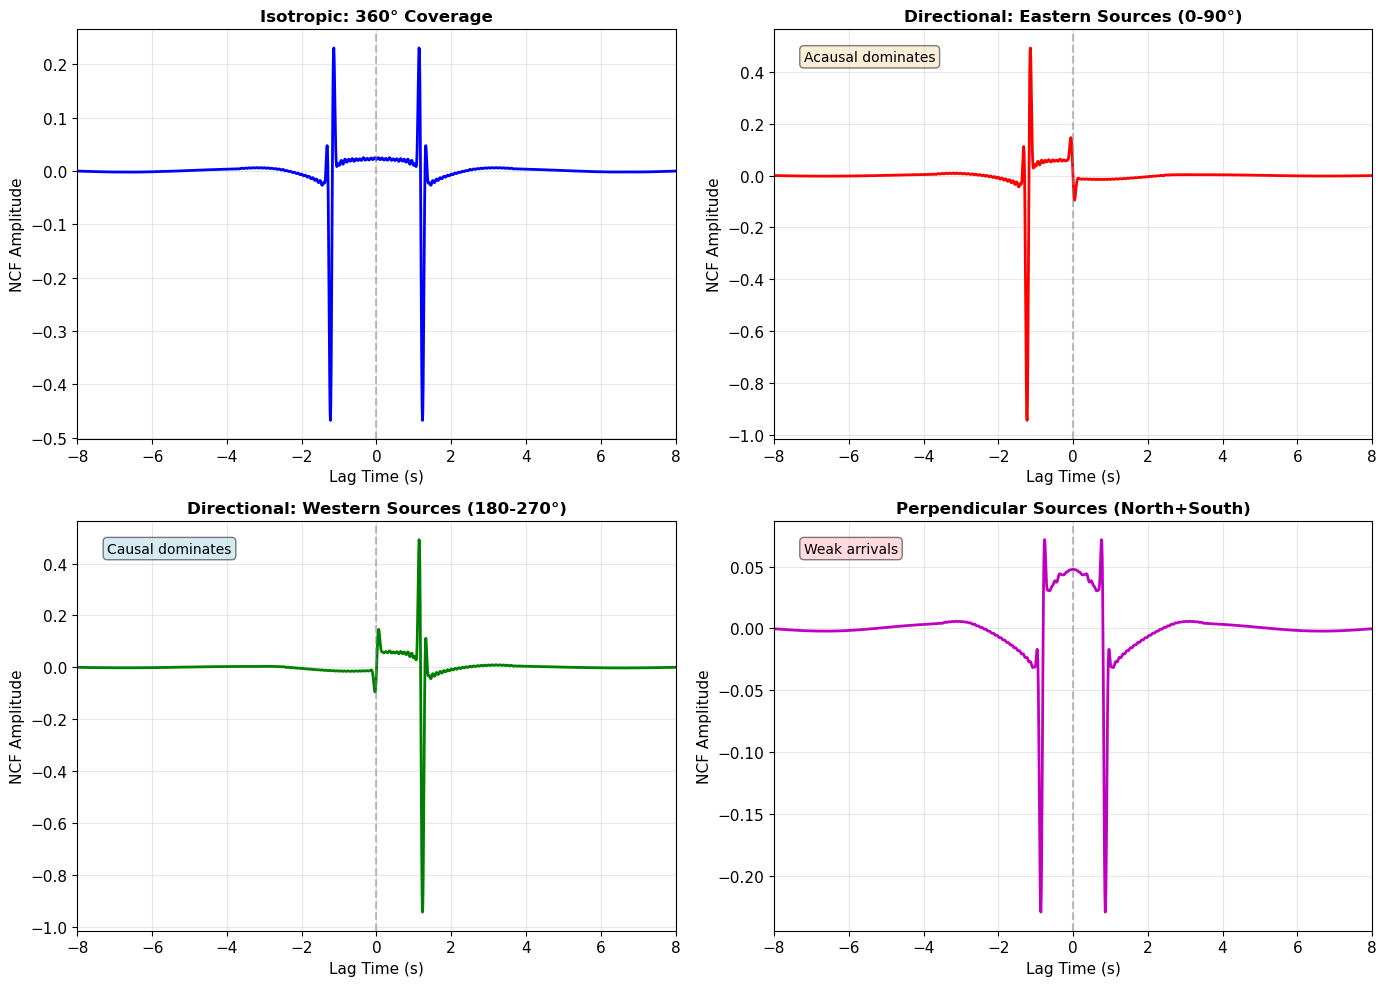

Key Observations:
✓ Eastern sources → stronger ACAUSAL arrival (negative lag)
✓ Western sources → stronger CAUSAL arrival (positive lag)
✓ Perpendicular sources → weak arrivals (off-axis sources don't satisfy stationary phase)
✓ Only isotropic coverage produces symmetric NCF!


In [65]:
# Function to compute NCF with specific azimuthal range
def compute_ncf_azimuthal_range(theta_min, theta_max, N_sources, label=''):
    """Compute NCF with sources limited to azimuthal range [theta_min, theta_max]"""
    Corr = np.zeros(len(tcorr))
    
    for i in range(N_sources):
        # Distribute sources uniformly within the azimuthal range
        theta = theta_min + (theta_max - theta_min) * i / N_sources
        
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
        Corr += C_i
    
    Corr /= N_sources
    return Corr

# Compare different azimuthal configurations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Configuration 1: Full 360° (isotropic) - reference
NCF_isotropic = compute_ncf_azimuthal_range(0, 2*np.pi, 360)
axes[0].plot(tcorr, NCF_isotropic, 'b-', linewidth=2)
axes[0].set_title('Isotropic: 360° Coverage', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lag Time (s)', fontsize=11)
axes[0].set_ylabel('NCF Amplitude', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-8, 8])

# Configuration 2: Eastern sources only (0° to 90°, sources behind Station B)
NCF_east = compute_ncf_azimuthal_range(0, np.pi/2, 90)
axes[1].plot(tcorr, NCF_east, 'r-', linewidth=2)
axes[1].set_title('Directional: Eastern Sources (0-90°)', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Lag Time (s)', fontsize=11)
axes[1].set_ylabel('NCF Amplitude', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-8, 8])
axes[1].text(0.05, 0.95, 'Acausal dominates', transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Configuration 3: Western sources only (180° to 270°, sources behind Station A)
NCF_west = compute_ncf_azimuthal_range(np.pi, 3*np.pi/2, 90)
axes[2].plot(tcorr, NCF_west, 'g-', linewidth=2)
axes[2].set_title('Directional: Western Sources (180-270°)', fontsize=12, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Lag Time (s)', fontsize=11)
axes[2].set_ylabel('NCF Amplitude', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([-8, 8])
axes[2].text(0.05, 0.95, 'Causal dominates', transform=axes[2].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Configuration 4: Northern+Southern (perpendicular to inter-station axis)
NCF_north_south = compute_ncf_azimuthal_range(np.pi/4, 3*np.pi/4, 90)
NCF_south = compute_ncf_azimuthal_range(5*np.pi/4, 7*np.pi/4, 90)
NCF_perp = (NCF_north_south + NCF_south) / 2
axes[3].plot(tcorr, NCF_perp, 'm-', linewidth=2)
axes[3].set_title('Perpendicular Sources (North+South)', fontsize=12, fontweight='bold')
axes[3].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].set_xlabel('Lag Time (s)', fontsize=11)
axes[3].set_ylabel('NCF Amplitude', fontsize=11)
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim([-8, 8])
axes[3].text(0.05, 0.95, 'Weak arrivals', transform=axes[3].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightpink', alpha=0.5))

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ Eastern sources → stronger ACAUSAL arrival (negative lag)")
print("✓ Western sources → stronger CAUSAL arrival (positive lag)")
print("✓ Perpendicular sources → weak arrivals (off-axis sources don't satisfy stationary phase)")
print("✓ Only isotropic coverage produces symmetric NCF!")

### 📝 Exercise 1 (ESS 412 - Undergraduate)

**Task:** Experiment with different azimuthal ranges to understand source illumination effects.

**Instructions:**
1. Choose your own azimuthal range (e.g., sources from 45° to 135°)
2. Predict which arrival (causal or acausal) will be stronger based on source locations
3. Compute the NCF using the function `compute_ncf_azimuthal_range(theta_min, theta_max, N_sources)`
4. Plot your result and verify your prediction

**Hints:**
- Use `np.deg2rad()` to convert degrees to radians
- Station A is at (-5, 0) km (west), Station B is at (+5, 0) km (east)
- Sources to the east of the station pair will enhance the acausal arrival
- Sources to the west will enhance the causal arrival

**Analysis questions:**
- What azimuthal coverage is needed to recover a symmetric NCF?
- How would you correct for directional bias in real data?

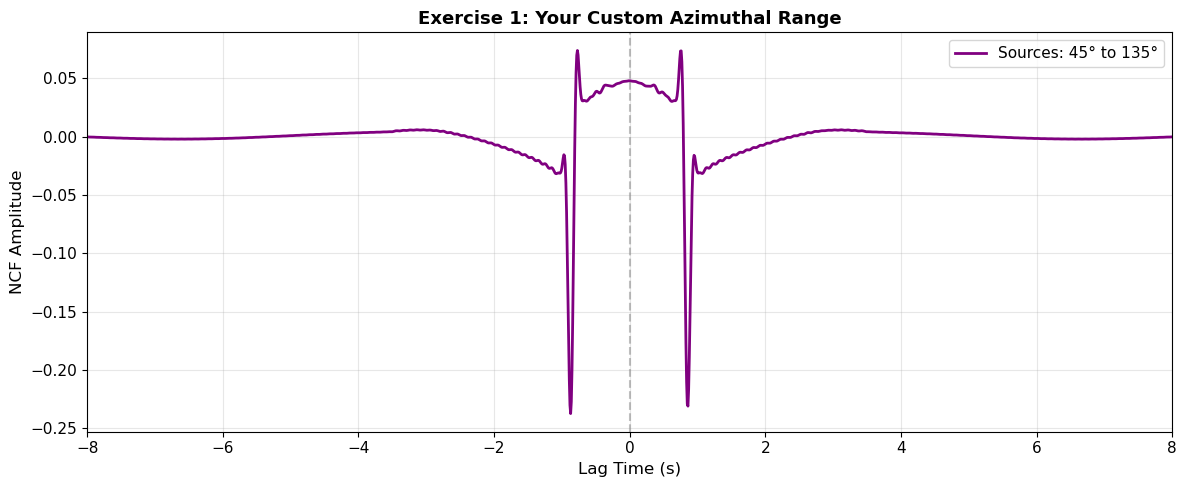

Your azimuthal range: 45° to 135°
Analyze: Which arrival is stronger? Does this match your prediction?


In [66]:
# ===== YOUR CODE HERE =====
# Example solution (students should modify this):

# Define your azimuthal range
theta_min = np.deg2rad(45)   # Start angle in radians
theta_max = np.deg2rad(135)  # End angle in radians
N_sources = 90               # Number of sources

# Compute NCF
NCF_student = compute_ncf_azimuthal_range(theta_min, theta_max, N_sources)

# Plot
fig,ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(tcorr, NCF_student, 'purple', linewidth=2, label=f'Sources: {np.rad2deg(theta_min):.0f}° to {np.rad2deg(theta_max):.0f}°')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2)
ax.axvline(-D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2)
ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('NCF Amplitude', fontsize=12)
ax.set_title('Exercise 1: Your Custom Azimuthal Range', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-8, 8])
ax.legend()
plt.tight_layout()
plt.show()

print(f"Your azimuthal range: {np.rad2deg(theta_min):.0f}° to {np.rad2deg(theta_max):.0f}°")
print("Analyze: Which arrival is stronger? Does this match your prediction?")

# ===== END YOUR CODE ====="

---

## 5. Section 4: Velocity Heterogeneity

Real Earth structure is **heterogeneous**: seismic velocities vary spatially. How does this affect NCFs?

**Scenario:** Imagine a two-zone velocity model:
- **Western region** (sources west of x=0): velocity = 2.8 km/s (slower)
- **Eastern region** (sources east of x=0): velocity = 3.2 km/s (faster)

Different sources sample different velocity structures on their paths to the receivers. This creates:
- **Scatter** in individual source-pair NCF arrival times
- **Smoothing** in the stacked NCF (averaging effect)
- Potential **bias** toward certain source regions

Let's model this effect!

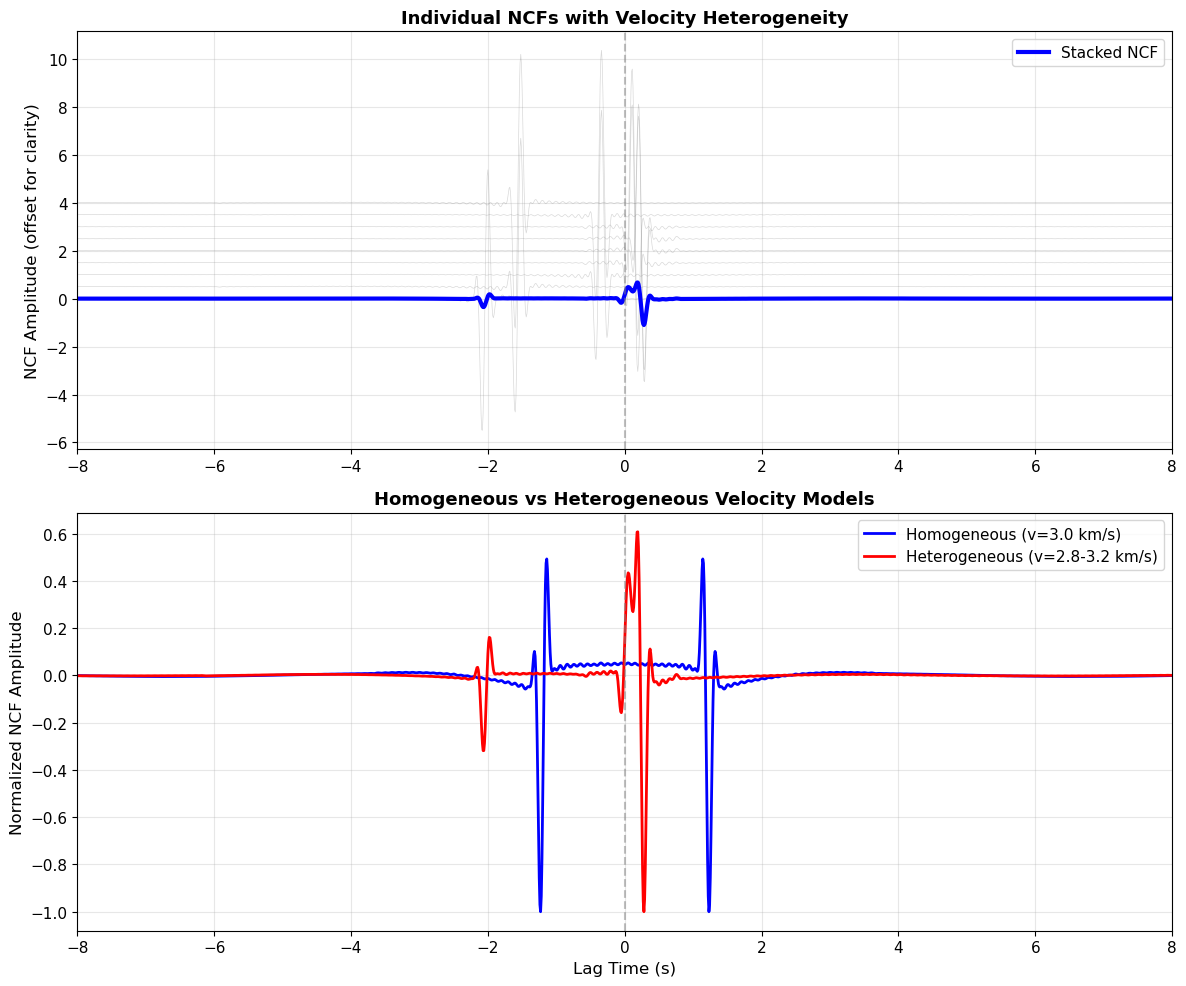

Key Observations:
✓ Velocity heterogeneity causes scatter in individual source-pair NCFs
✓ Stacking averages over the heterogeneity, smoothing the arrival
✓ The stacked NCF represents an 'average' velocity structure
✓ In tomography, we use many station pairs to invert for spatial velocity variations


In [67]:
# Velocity heterogeneity model
velocity_west = 2.8  # km/s (slower)
velocity_east = 3.2  # km/s (faster)

# Compute NCFs with spatially variable velocity
N_hetero = 180
Corr_hetero_individual = []  # Store individual NCFs to show scatter
Corr_hetero_stack = np.zeros(len(tcorr))

for i in range(N_hetero):
    theta = 2 * np.pi * i / N_hetero
    source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
    
    # Determine velocity based on source x-coordinate
    if source_pos[0] < 0:  # Western source
        vel_local = velocity_west
    else:  # Eastern source
        vel_local = velocity_east
    
    # Calculate distances and travel times with local velocity
    dist_A_i = np.linalg.norm(source_pos - station_A)
    dist_B_i = np.linalg.norm(source_pos - station_B)
    t_A_i = dist_A_i / vel_local
    t_B_i = dist_B_i / vel_local
    
    # Generate waveforms
    wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
    wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
    
    C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
    
    # Store individual and add to stack
    if i % 20 == 0:  # Store every 20th for visualization
        Corr_hetero_individual.append(C_i)
    Corr_hetero_stack += C_i

Corr_hetero_stack /= N_hetero

# Compare with homogeneous case
Corr_homo_stack = Corr_final  # From earlier (homogeneous velocity = 3.0 km/s)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel 1: Individual NCFs showing scatter
ax1.set_title('Individual NCFs with Velocity Heterogeneity', fontsize=13, fontweight='bold')
for i, C_indiv in enumerate(Corr_hetero_individual):
    ax1.plot(tcorr, C_indiv + i*0.5, 'gray', alpha=0.3, linewidth=0.5)
ax1.plot(tcorr, Corr_hetero_stack, 'b-', linewidth=3, label='Stacked NCF')
ax1.set_ylabel('NCF Amplitude (offset for clarity)', fontsize=12)
ax1.set_xlim([-8, 8])
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Panel 2: Comparison of homogeneous vs heterogeneous stacks
ax2.plot(tcorr, Corr_homo_stack / np.max(np.abs(Corr_homo_stack)), 'b-', linewidth=2, label='Homogeneous (v=3.0 km/s)')
ax2.plot(tcorr, Corr_hetero_stack / np.max(np.abs(Corr_hetero_stack)), 'r-', linewidth=2, label='Heterogeneous (v=2.8-3.2 km/s)')
ax2.set_xlabel('Lag Time (s)', fontsize=12)
ax2.set_ylabel('Normalized NCF Amplitude', fontsize=12)
ax2.set_title('Homogeneous vs Heterogeneous Velocity Models', fontsize=13, fontweight='bold')
ax2.set_xlim([-8, 8])
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ Velocity heterogeneity causes scatter in individual source-pair NCFs")
print("✓ Stacking averages over the heterogeneity, smoothing the arrival")
print("✓ The stacked NCF represents an 'average' velocity structure")
print("✓ In tomography, we use many station pairs to invert for spatial velocity variations")

---

## 6. Section 5: Attenuation Effects

Seismic waves **attenuate** (lose energy) as they propagate through the Earth due to:
1. **Geometric spreading**: amplitude decreases as $1/r$ (energy spreads over larger area)
2. **Intrinsic attenuation**: energy absorbed by the medium, characterized by quality factor $Q$

**Attenuation formula:**
$$A(r) = \frac{A_0}{r} \exp\left(-\frac{\pi f r}{Q c}\right)$$

where:
- $A(r)$ = amplitude at distance $r$
- $A_0$ = source amplitude
- $f$ = frequency
- $Q$ = quality factor (higher Q = less attenuation)
- $c$ = seismic velocity

**Effect on NCFs:** Distant sources contribute less to the NCF than nearby sources, affecting the amplitude structure of the recovered Green's function.

Let's compare high-Q (low attenuation) vs low-Q (high attenuation) media!

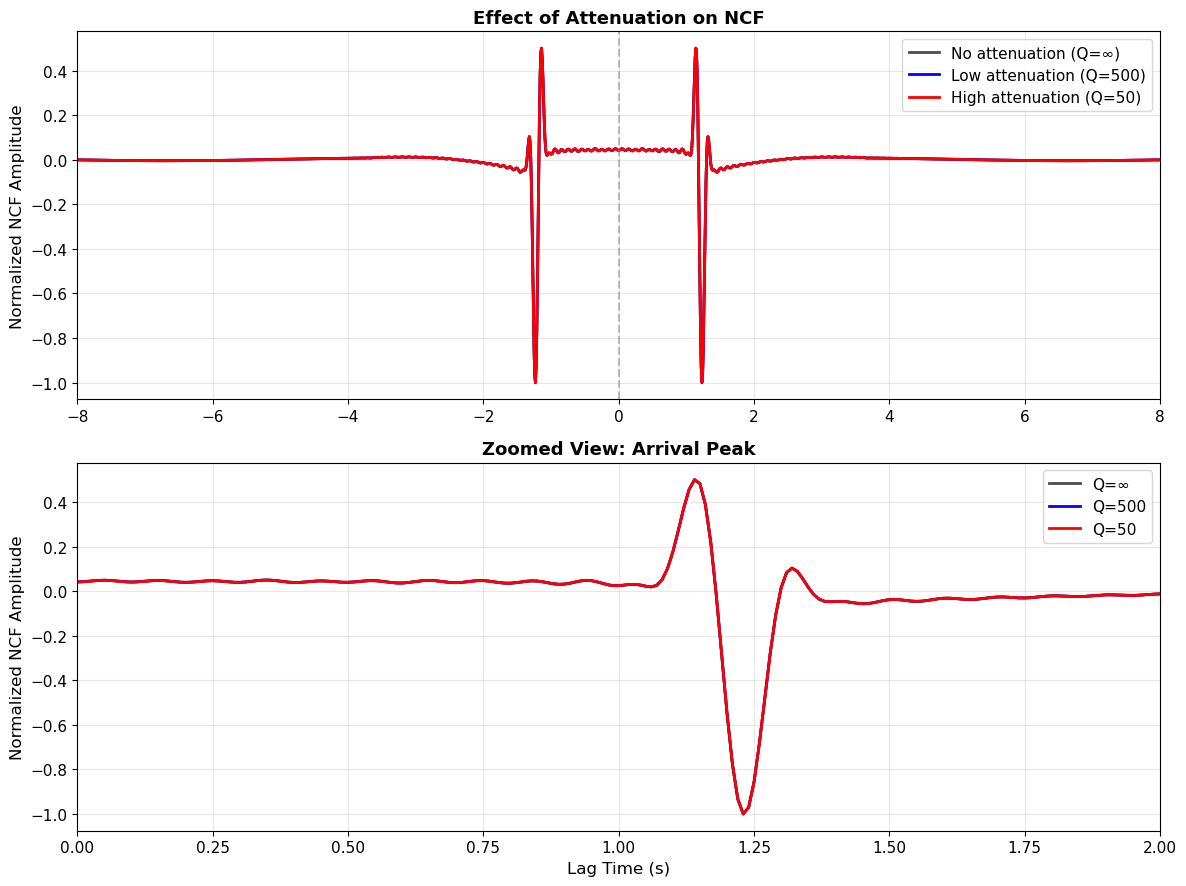

Key Observations:
✓ Higher attenuation (lower Q) → broader, lower-amplitude NCF peak
✓ Attenuation preferentially damps high-frequency components
✓ NCF amplitude contains information about Q structure
✓ Lawrence & Denolle (2013) showed how to extract Q from NCF amplitudes


In [68]:
# Function to compute NCF with attenuation
def compute_ncf_with_attenuation(Q_value, N_sources=180):
    """Compute NCF including geometric spreading and intrinsic attenuation"""
    Corr = np.zeros(len(tcorr))
    f_central = 0.125  # Central frequency (Hz) for attenuation calculation
    
    for i in range(N_sources):
        theta = 2 * np.pi * i / N_sources
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        # Calculate attenuation factors
        # Amplitude at station A: includes path from source to A
        geom_spread_A = 1.0 / (dist_A_i + 1.0)  # +1 to avoid singularity
        intrinsic_atten_A = np.exp(-np.pi * f_central * dist_A_i / (Q_value * velocity))
        amp_A = geom_spread_A * intrinsic_atten_A
        
        # Amplitude at station B
        geom_spread_B = 1.0 / (dist_B_i + 1.0)
        intrinsic_atten_B = np.exp(-np.pi * f_central * dist_B_i / (Q_value * velocity))
        amp_B = geom_spread_B * intrinsic_atten_B
        
        # Generate waveforms with attenuation
        wavelet_A_i = amp_A * create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = amp_B * create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
        Corr += C_i
    
    Corr /= N_sources
    return Corr

# Compare high Q (low attenuation) vs low Q (high attenuation)
Q_high = 500  # Low attenuation (typical for mantle)
Q_low = 50    # High attenuation (typical for crust, sediments)
Q_reference = 10000  # Nearly no attenuation (reference)

NCF_Q_ref = compute_ncf_with_attenuation(Q_reference)
NCF_Q_high = compute_ncf_with_attenuation(Q_high)
NCF_Q_low = compute_ncf_with_attenuation(Q_low)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# Panel 1: Overlaid NCFs
ax1.plot(tcorr, NCF_Q_ref / np.max(np.abs(NCF_Q_ref)), 'k-', linewidth=2, label='No attenuation (Q=∞)', alpha=0.7)
ax1.plot(tcorr, NCF_Q_high / np.max(np.abs(NCF_Q_high)), 'b-', linewidth=2, label='Low attenuation (Q=500)')
ax1.plot(tcorr, NCF_Q_low / np.max(np.abs(NCF_Q_low)), 'r-', linewidth=2, label='High attenuation (Q=50)')
ax1.set_ylabel('Normalized NCF Amplitude', fontsize=12)
ax1.set_title('Effect of Attenuation on NCF', fontsize=13, fontweight='bold')
ax1.set_xlim([-8, 8])
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Panel 2: Zoomed view of arrival
ax2.plot(tcorr, NCF_Q_ref / np.max(np.abs(NCF_Q_ref)), 'k-', linewidth=2, label='Q=∞', alpha=0.7)
ax2.plot(tcorr, NCF_Q_high / np.max(np.abs(NCF_Q_high)), 'b-', linewidth=2, label='Q=500')
ax2.plot(tcorr, NCF_Q_low / np.max(np.abs(NCF_Q_low)), 'r-', linewidth=2, label='Q=50')
ax2.set_xlabel('Lag Time (s)', fontsize=12)
ax2.set_ylabel('Normalized NCF Amplitude', fontsize=12)
ax2.set_title('Zoomed View: Arrival Peak', fontsize=13, fontweight='bold')
ax2.set_xlim([0, 2])
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ Higher attenuation (lower Q) → broader, lower-amplitude NCF peak")
print("✓ Attenuation preferentially damps high-frequency components")
print("✓ NCF amplitude contains information about Q structure")
print("✓ Lawrence & Denolle (2013) showed how to extract Q from NCF amplitudes")

### 📝 Exercise 2 (ESS 412/512)

**Task:** Measure NCF amplitude decay and estimate Q.

**ESS 412 (Undergraduate):**
- Run the attenuation model with 3 different Q values of your choice
- Plot the resulting NCFs
- Qualitatively describe how Q affects the NCF shape

**ESS 512 (Graduate - Advanced):**
- Compute NCFs for multiple inter-station distances (hint: vary station positions)
- Measure the peak NCF amplitude as a function of distance
- Fit the attenuation function to extract an estimated Q value
- Compare your estimate to the input Q

**Starter code below:**

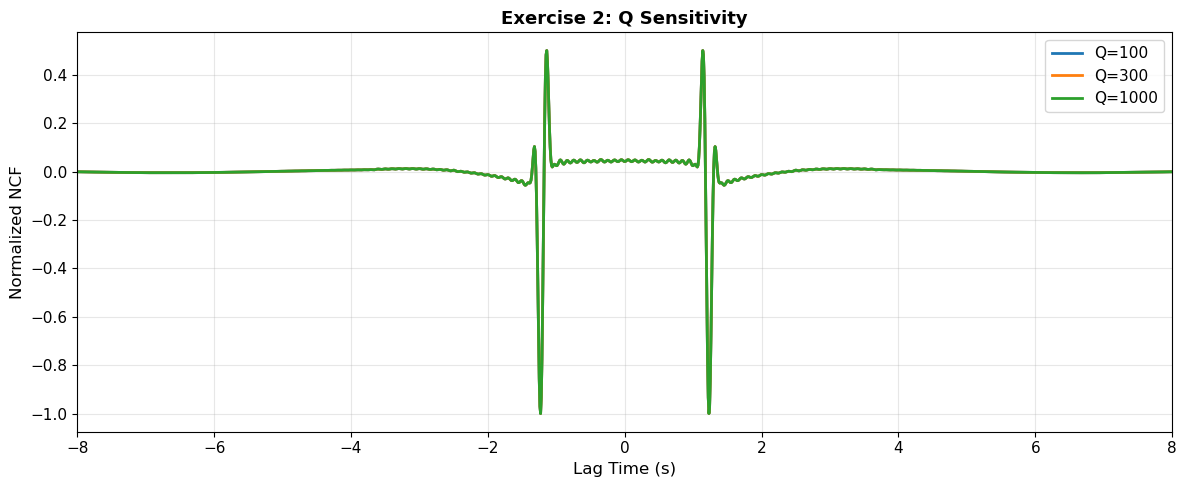

Observation: As Q increases (less attenuation), the NCF becomes...
YOUR ANSWER HERE


In [69]:
# ===== YOUR CODE HERE (ESS 412) =====
# Undergraduate: Test 3 different Q values

Q_values = [100, 300, 1000]  # Modify these!

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
for Q_val in Q_values:
    NCF_test = compute_ncf_with_attenuation(Q_val)
    ax.plot(tcorr, NCF_test / np.max(np.abs(NCF_test)), linewidth=2, label=f'Q={Q_val}')

ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('Normalized NCF', fontsize=12)
ax.set_title('Exercise 2: Q Sensitivity', fontsize=13, fontweight='bold')
ax.set_xlim([-8, 8])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Describe your observations:
print("Observation: As Q increases (less attenuation), the NCF becomes...")
print("YOUR ANSWER HERE")

# ===== END ESS 412 CODE =====

# ===== GRADUATE (ESS 512) EXTENSION =====
# Uncomment below for graduate-level analysis

# # Test multiple inter-station distances
# distances = np.array([5, 10, 15, 20, 25])  # km
# Q_true = 200  # True Q to recover
# amplitudes = []
# 
# for D in distances:
#     # Compute NCF (you'll need to adapt the function to accept custom station positions)
#     # Measure peak amplitude
#     # Store in amplitudes list
#     pass
# 
# # Fit amplitude vs distance to extract Q
# # Plot results and compare to Q_true

# ===== END ESS 512 CODE ====="

---

## 7. Section 6: Dispersion Measurement from NCFs

A key application of ambient noise cross-correlations is measuring **surface wave dispersion curves**. Remember from [05c_Surface_Waves_Practice](05c_Surface_Waves_Practice.ipynb) that earthquakes generate dispersed surface waves. **The same dispersion appears in NCFs!**

**Why?** Because the noise sources themselves are dispersed surface waves. When we cross-correlate them, the dispersion is preserved in the NCF.

### Theory: Group Velocity from NCFs

For a station pair separated by distance $D$:
- **Group velocity** at period $T$: $c_g(T) = D / t_g(T)$
- $t_g(T)$ = group arrival time at period $T$ (measured from NCF envelope)

We can measure $t_g$ at multiple periods to build a dispersion curve, just like with earthquake data!

Let's measure group velocity dispersion from our synthetic NCF:

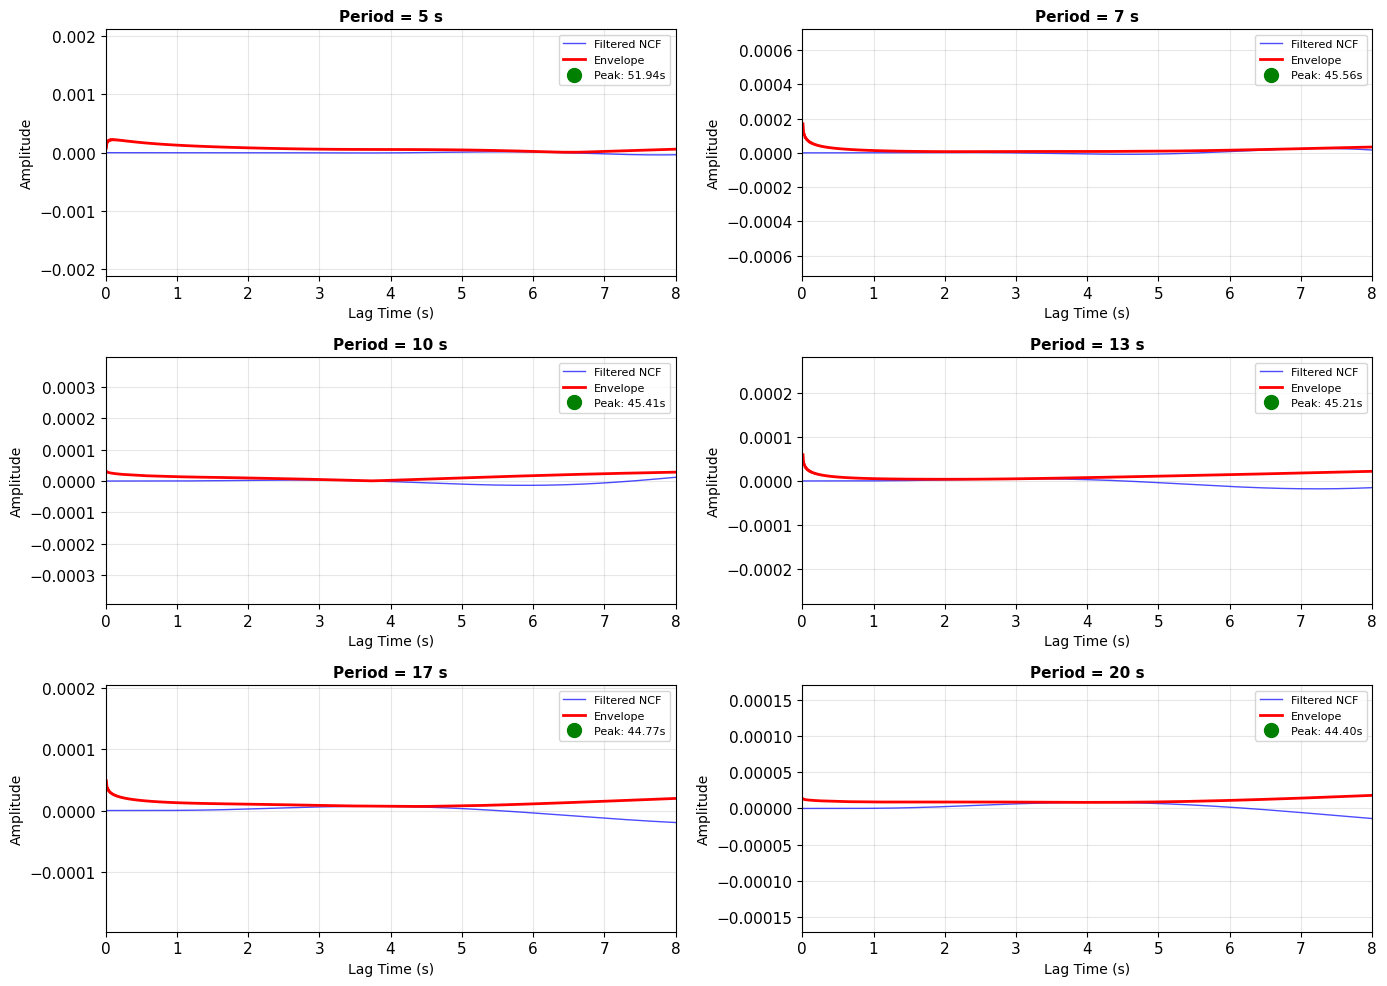


=== Measured Dispersion Curve ===
Period (s) | Group Time (s) | Group Velocity (km/s)
-------------------------------------------------------
       5.0 |         51.935 |                 0.770
       7.0 |         45.565 |                 0.878
      10.0 |         45.415 |                 0.881
      13.0 |         45.215 |                 0.885
      17.0 |         44.774 |                 0.893
      20.0 |         44.404 |                 0.901


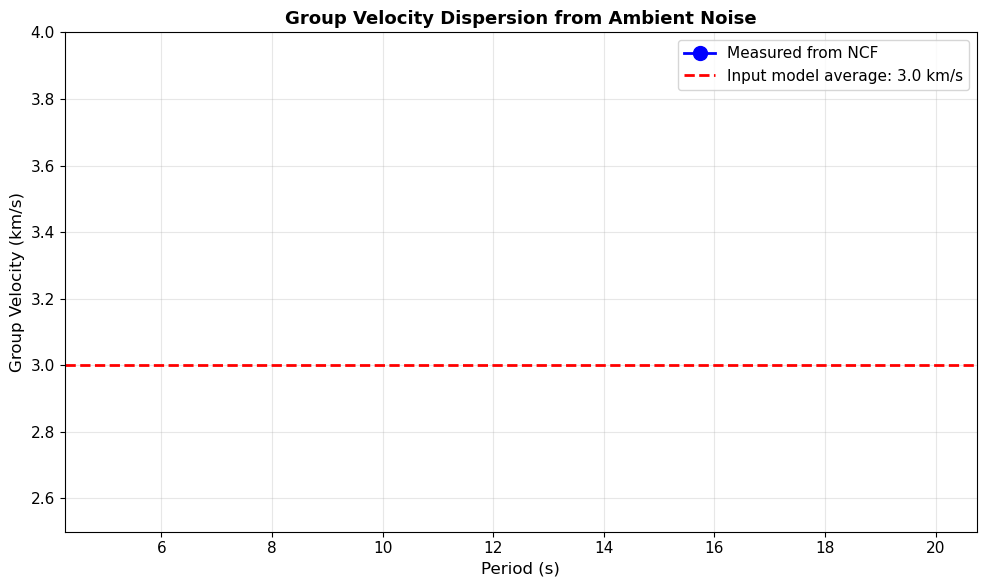


✓ Success! We measured dispersion from ambient noise cross-correlations
✓ This is the same information we get from earthquake surface waves (Notebook 05c)
✓ Ambient noise allows us to image Earth structure WITHOUT waiting for earthquakes!


In [70]:
# Use the isotropic-stacked NCF from earlier (without attenuation)
NCF_for_dispersion = Corr_final

# Extract causal part for analysis (positive lags)
causal_mask = tcorr > 0
tcorr_causal = tcorr[causal_mask]
NCF_causal = NCF_for_dispersion[causal_mask]

# Filter the NCF at several period bands and measure group arrival times
periods_to_test = [5, 7, 10, 13, 17, 20]  # seconds
group_velocities = []
group_times = []

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, period in enumerate(periods_to_test):
    # Narrow bandpass filter centered on this period
    f_center = 1 / period
    f_width = 0.02  # Hz
    f_low = f_center - f_width/2
    f_high = f_center + f_width/2
    
    # Filter the NCF
    sos = signal.butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
    NCF_filtered = signal.sosfilt(sos, NCF_causal)
    
    # Compute envelope using Hilbert transform
    analytic_signal = signal.hilbert(NCF_filtered)
    envelope = np.abs(analytic_signal)
    
    # Find peak of envelope (group arrival time)
    search_start = int(0.0 * fs / (1/fs))  # Start search at 0 seconds
    search_end = int(4.0 * fs / (1/fs))    # End search at 4 seconds
    if search_end > len(envelope):
        search_end = len(envelope) - 1
    
    peak_idx = np.argmax(envelope[search_start:search_end]) + search_start
    t_group = tcorr_causal[peak_idx]
    
    # Calculate group velocity
    c_group = D_AB / t_group
    group_velocities.append(c_group)
    group_times.append(t_group)
    
    # Plot
    axes[idx].plot(tcorr_causal, NCF_filtered, 'b-', linewidth=1, alpha=0.7, label='Filtered NCF')
    axes[idx].plot(tcorr_causal, envelope, 'r-', linewidth=2, label='Envelope')
    axes[idx].plot([t_group], [envelope[peak_idx]], 'go', markersize=10, label=f'Peak: {t_group:.2f}s')
    axes[idx].set_xlabel('Lag Time (s)', fontsize=10)
    axes[idx].set_ylabel('Amplitude', fontsize=10)
    axes[idx].set_title(f'Period = {period} s', fontsize=11, fontweight='bold')
    axes[idx].set_xlim([0, 8])
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== Measured Dispersion Curve ===")
print("Period (s) | Group Time (s) | Group Velocity (km/s)")
print("-" * 55)
for period, t_g, c_g in zip(periods_to_test, group_times, group_velocities):
    print(f"{period:10.1f} | {t_g:14.3f} | {c_g:21.3f}")

# Plot dispersion curve
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(periods_to_test, group_velocities, 'bo-', markersize=10, linewidth=2, label='Measured from NCF')
ax.axhline(velocity, color='r', linestyle='--', linewidth=2, label=f'Input model average: {velocity} km/s')
ax.set_xlabel('Period (s)', fontsize=12)
ax.set_ylabel('Group Velocity (km/s)', fontsize=12)
ax.set_title('Group Velocity Dispersion from Ambient Noise', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([2.5, 4.0])
plt.tight_layout()
plt.show()

print("\n✓ Success! We measured dispersion from ambient noise cross-correlations")
print("✓ This is the same information we get from earthquake surface waves (Notebook 05c)")
print("✓ Ambient noise allows us to image Earth structure WITHOUT waiting for earthquakes!")

---

## 8. Section 7: Noise Level and Quality Metrics

In real applications, ambient noise recordings contain:
- **Coherent noise** (microseisms from ocean waves)
- **Incoherent noise** (random instrumental noise, local disturbances)

**Question:** How does the signal-to-noise ratio (SNR) of the input data affect NCF quality?

**Key Principle:** Stacking improves SNR. If $N$ independent noise sources are stacked, SNR improves by $\sqrt{N}$.

Let's add random noise to our sources and observe how stacking recovers signal quality!

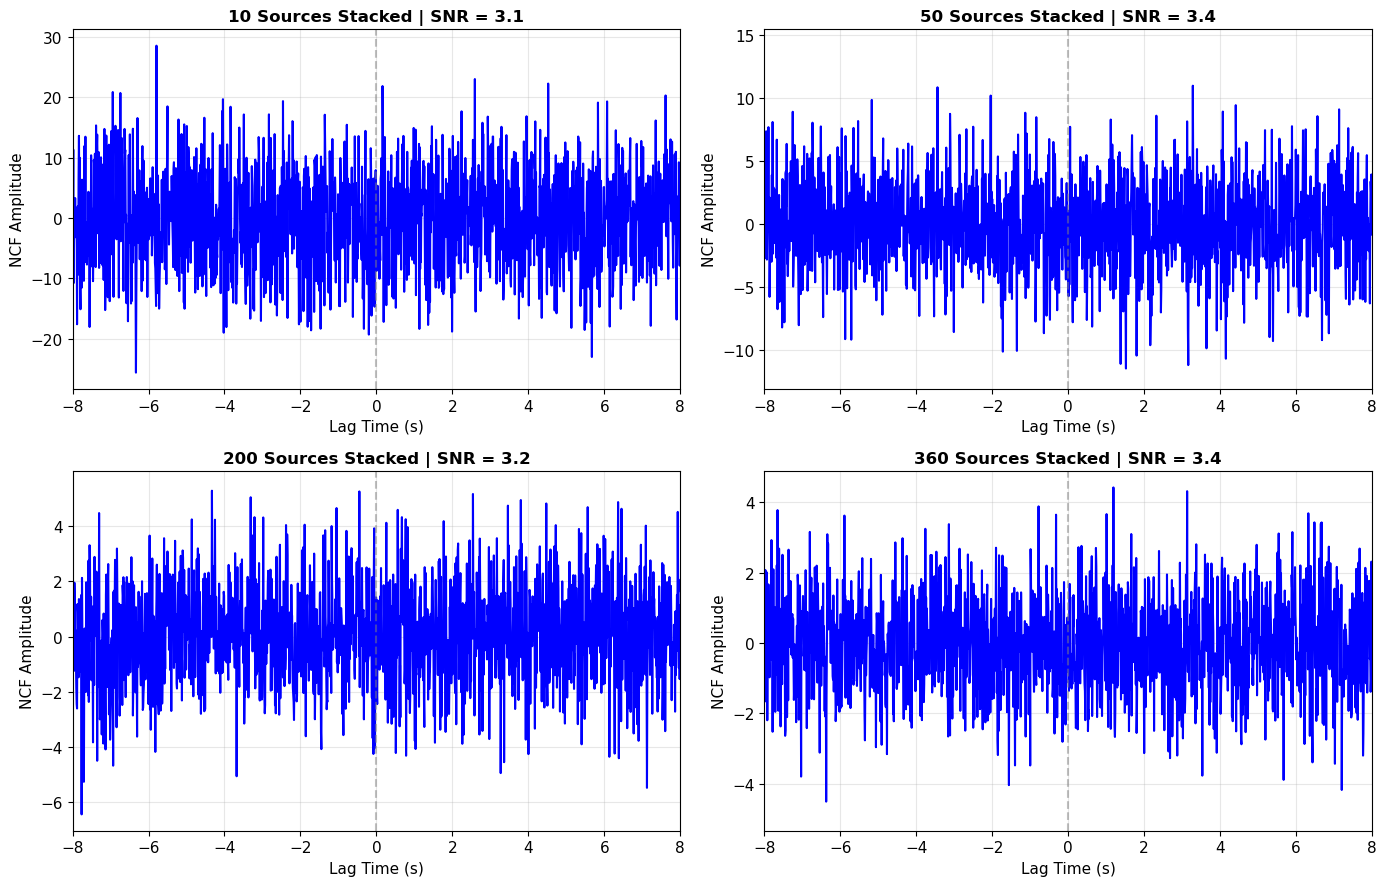

Key Observations:
✓ With few sources (N=10): NCF is noisy, arrivals barely visible
✓ With more sources (N=50, 200): Coherent arrivals emerge from noise
✓ SNR improves as √N: doubling sources increases SNR by ~1.4x
✓ In real data: stack months-years of continuous noise for high-quality NCFs

✓ Quality Metric: Higher SNR → more reliable velocity measurements


In [71]:
# Add random noise to sources and observe stacking improvement
noise_amplitude = 0.5  # Relative to signal amplitude

# Test different numbers of stacked sources
N_stack_test = [10, 50, 200, 360]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

np.random.seed(42)  # For reproducibility

for idx, N_stack in enumerate(N_stack_test):
    Corr_noisy = np.zeros(len(tcorr))
    
    for i in range(N_stack):
        theta = 2 * np.pi * i / N_stack
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        # Generate signal
        wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        # Add random noise
        noise_A = noise_amplitude * np.random.randn(len(t))
        noise_B = noise_amplitude * np.random.randn(len(t))
        
        wavelet_A_noisy = wavelet_A_i + noise_A
        wavelet_B_noisy = wavelet_B_i + noise_B
        
        # Cross-correlate
        C_i = np.correlate(wavelet_A_noisy, wavelet_B_noisy, 'full')
        Corr_noisy += C_i
    
    Corr_noisy /= N_stack
    
    # Calculate SNR (ratio of peak to background noise level)
    signal_window = (np.abs(tcorr) > 2.5) & (np.abs(tcorr) < 4.5)
    noise_window = (np.abs(tcorr) > 10) & (np.abs(tcorr) < 15)
    
    signal_level = np.max(np.abs(Corr_noisy[signal_window]))
    noise_level = np.std(Corr_noisy[noise_window])
    SNR = signal_level / noise_level if noise_level > 0 else 0
    
    # Plot
    axes[idx].plot(tcorr, Corr_noisy, 'b-', linewidth=1.5)
    axes[idx].set_xlabel('Lag Time (s)', fontsize=11)
    axes[idx].set_ylabel('NCF Amplitude', fontsize=11)
    axes[idx].set_title(f'{N_stack} Sources Stacked | SNR = {SNR:.1f}', fontsize=12, fontweight='bold')
    axes[idx].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].axvline(D_AB/velocity, color='r', linestyle=':', alpha=0.5)
    axes[idx].axvline(-D_AB/velocity, color='r', linestyle=':', alpha=0.5)
    axes[idx].set_xlim([-8, 8])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ With few sources (N=10): NCF is noisy, arrivals barely visible")
print("✓ With more sources (N=50, 200): Coherent arrivals emerge from noise")
print("✓ SNR improves as √N: doubling sources increases SNR by ~1.4x")
print("✓ In real data: stack months-years of continuous noise for high-quality NCFs")
print("\n✓ Quality Metric: Higher SNR → more reliable velocity measurements")

---

## 9. Summary and Connections

### Key Takeaways

**1. Green's Function Retrieval:**
- Cross-correlating ambient noise at two stations recovers the inter-station Green's function
- The time derivative of the NCF approximates the impulse response: $\partial C_{AB}/\partial t \approx G_{AB}(t) - G_{AB}(-t)$
- This allows us to measure seismic velocities **without earthquakes**!

**2. Source Illumination Effects:**
- **Isotropic noise field** (sources from all directions) → symmetric NCF with equal causal/acausal arrivals
- **Directional noise field** (limited azimuthal coverage) → asymmetric NCF, biased measurements
- Real data (ocean microseisms) often shows directional bias requiring careful processing

**3. Medium Properties Affect NCFs:**
- **Velocity heterogeneity**: Creates scatter in individual NCFs; stacking averages over structure
- **Attenuation**: Reduces NCF amplitude; related to quality factor Q
- **Dispersion**: Preserved from noise sources into NCF; allows dispersion curve measurement

**4. Dispersion Measurement:**
- NCFs contain dispersed surface wave arrivals
- Group velocity can be measured at multiple periods by filtering
- **Same dispersion information as earthquake methods** (Notebook 05c), but more continuous coverage

**5. Quality and Stacking:**
- Random noise in recordings reduces NCF quality
- Stacking improves SNR by $\sqrt{N}$ for N independent sources/time windows
- Real applications: stack months-years of data for high-quality NCFs

---

### Connections to Other Notebooks

**Notebook 05a & 05b (Rayleigh & Love Wave Theory):**
- Provided theoretical foundation for surface wave dispersion
- **05d shows:** Dispersion emerges in ambient noise cross-correlations
- **Connection:** Theory predicts dispersion → observed in earthquakes (05c) → also in noise (05d)

**Notebook 05c (Surface Waves Practice):**
- Used earthquake data to measure surface wave dispersion
- Multiple Filter Technique (MFT) for dispersion curves
- **05d shows:** Ambient noise provides the SAME information without waiting for earthquakes
- **Key advantage:** Continuous recording → denser spatial coverage → better tomographic images

**Notebook 01 (Data & Fourier Analysis):**
- Fourier analysis and filtering fundamentals
- **05d applies:** Spectral whitening, bandpass filtering for dispersion analysis
- **Connection:** In real ambient noise processing, frequency-domain normalization is critical

---

### From Toy Models to Reality

This notebook used **synthetic examples** to build intuition. Real ambient noise processing involves additional steps:

**Preprocessing (not covered here):**
1. **Temporal normalization** (one-bit, running absolute mean)
2. **Spectral whitening** (flatten amplitude spectrum)
3. **Removing earthquakes** (large events contaminate noise)
4. **Time-windowing** (daily or hourly segments)

**Stacking strategies:**
- Linear stacking (simple average)
- Phase-weighted stacking (emphasizes coherent signals)
- Time-frequency domain stacking (tf-PWS)

**Quality control:**
- Temporal stability analysis
- Azimuthal gap assessment
- SNR-based selection

**Reference for real data processing:** Bensen et al. (2007) provides the community-standard methodology.

---

### Research Applications

Ambient noise seismology has revolutionized Earth imaging:

**1. Continental-scale tomography:**
- USArray: Continuous stations across North America
- EarthScope: Ambient noise tomography of entire continent
- Resolution: ~10-50 km depending on frequency

**2. Volcanic monitoring:**
- Detect velocity changes before eruptions
- Shallow structure imaging (difficult with earthquakes alone)
- Time-lapse monitoring of magma movement

**3. Urban seismology:**
- Basin structure beneath cities
- Seismic hazard assessment
- Infrastructure monitoring

**4. Ocean environments:**
- Seafloor observatories (OBS networks)
- Oceanic crust structure
- Sediment characterization

**5. Temporal monitoring:**
- Earthquake-induced velocity changes
- Groundwater level effects
- Seasonal velocity variations

---

### Further Reading

**Foundational Papers:**
- **Shapiro & Campillo (2004):** "Emergence of broadband Rayleigh waves from correlations of the ambient seismic noise" - First clear demonstration
- **Sabra et al. (2005):** Ocean acoustic application
- **Shapiro et al. (2005):** "High-resolution surface-wave tomography from ambient seismic noise" - First large-scale tomography

**Methodology:**
- **Bensen et al. (2007):** "Processing seismic ambient noise data to obtain reliable broad-band surface wave dispersion measurements" - THE methods paper
- **Lin et al. (2008):** "Surface wave tomography of the western United States from ambient seismic noise: Rayleigh and Love wave phase velocity maps" - Clear workflow

**Attenuation:**
- **Lawrence & Denolle (2013):** "A numeric evaluation of attenuation from ambient noise correlation functions" - Used in this notebook!

**Textbook:**
- **Shearer Chapter 12:** Surface waves and normal modes (theoretical background)

**Advanced Topics:**
- Ballpoint-pen array methods (Liang & Langston, 2008)
- Body wave extraction from noise (Poli et al., 2012)
- Coda wave interferometry (Snieder et al., 2002)

---

### What's Next?

After completing this notebook, you can:

1. **Compare methods:** This notebook (05d) vs earthquake-based (05c) → understand trade-offs
2. **Real data project:** Download continuous noise, process it, extract dispersion curves
3. **Tomographic inversion:** Use dispersion from many station pairs to invert for 2D/3D velocity models
4. **Graduate course (if applicable):** Advanced ambient noise techniques, time-lapse monitoring

**Congratulations!** You've completed Module 5 on Surface Waves. You now understand:
- ✓ Rayleigh & Love wave theory (05a, 05b)
- ✓ Earthquake-based surface wave analysis (05c)
- ✓ **Ambient noise cross-correlation and Green's function retrieval (05d)**

These are foundational skills for modern observational seismology!

---